# Import Modules

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Process the data

## 22. Statlog Heart Disease

In [5]:
df_statlog = pd.read_csv('data/22-statlog.csv')
df_statlog.head()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


## 23. Coronary Heart Disease

In [6]:
df_coronary = pd.read_csv('data/23-chd.csv')
df_coronary.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


---
# EDA — Exploratory Data Analysis

## Shape & Basic Info

In [7]:
print('=== 22. Statlog Heart Disease ===')
print(f'  Rows: {df_statlog.shape[0]}   Columns: {df_statlog.shape[1]}')
print()
df_statlog.info()

=== 22. Statlog Heart Disease ===
  Rows: 270   Columns: 14

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   270 non-null    float64
 1   sex                   270 non-null    float64
 2   chest-pain            270 non-null    float64
 3   rest-bp               270 non-null    float64
 4   serum-chol            270 non-null    float64
 5   fasting-blood-sugar   270 non-null    float64
 6   electrocardiographic  270 non-null    float64
 7   max-heart-rate        270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  major-vessels         270 non-null    float64
 12  thal                  270 non-null    float64
 13  heart-disease         270 non-null    int64  
dtypes: float64(13), int64(1)

In [8]:
print('=== 23. Coronary Heart Disease ===')
print(f'  Rows: {df_coronary.shape[0]}   Columns: {df_coronary.shape[1]}')
print()
df_coronary.info()

=== 23. Coronary Heart Disease ===
  Rows: 462   Columns: 10

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    str    
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 36.2 KB


## Descriptive Statistics

In [9]:
print('=== 22. Statlog — descriptive stats ===')
df_statlog.describe().round(2)

=== 22. Statlog — descriptive stats ===


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,54.43,0.68,3.17,131.34,249.66,0.15,1.02,149.68,0.33,1.05,1.59,0.67,4.70,1.44
std,9.11,0.47,0.95,17.86,51.69,0.36,1.00,23.17,0.47,1.15,0.61,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,1.00
25%,48.00,0.00,3.00,120.00,213.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,1.00
50%,55.00,1.00,3.00,130.00,245.00,0.00,2.00,153.50,0.00,0.80,2.00,0.00,3.00,1.00
75%,61.00,1.00,4.00,140.00,280.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,2.00


In [10]:
print('=== 23. Coronary — descriptive stats ===')
df_coronary.describe().round(2)

=== 23. Coronary — descriptive stats ===


,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00
mean,138.33,3.64,4.74,25.41,53.10,26.04,17.04,42.82,0.35
std,20.50,4.59,2.07,7.78,9.82,4.21,24.48,14.61,0.48
min,101.00,0.00,0.98,6.74,13.00,14.70,0.00,15.00,0.00
25%,124.00,0.05,3.28,19.77,47.00,22.98,0.51,31.00,0.00
50%,134.00,2.00,4.34,26.12,53.00,25.80,7.51,45.00,0.00
75%,148.00,5.50,5.79,31.23,60.00,28.50,23.89,55.00,1.00
max,218.00,31.20,15.33,42.49,78.00,46.58,147.19,64.00,1.00


## Missing Values

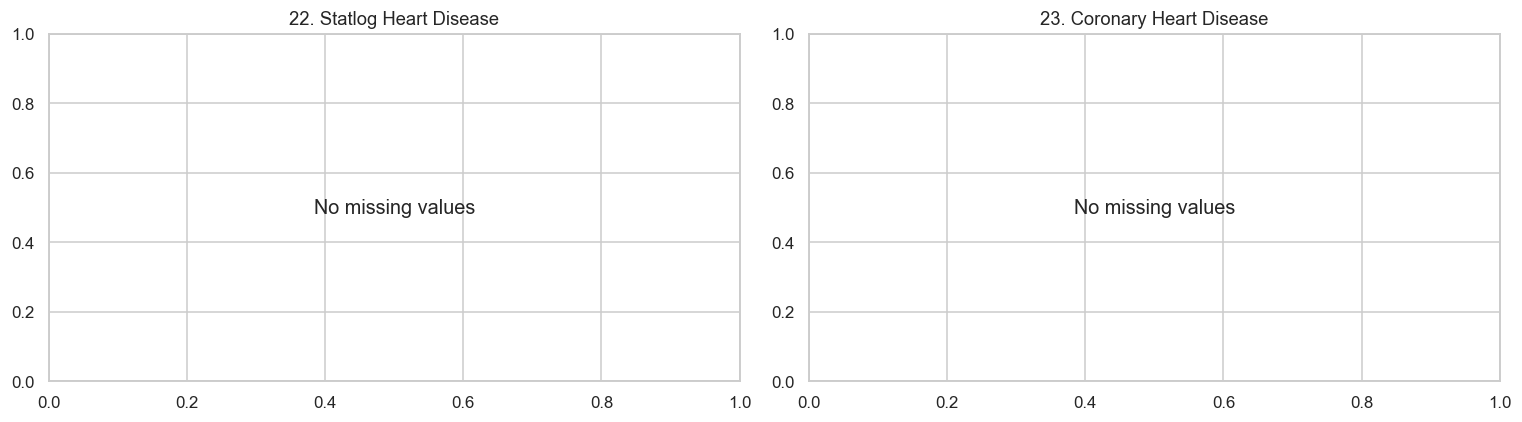

Statlog nulls:
age                     0
sex                     0
chest-pain              0
rest-bp                 0
serum-chol              0
fasting-blood-sugar     0
electrocardiographic    0
max-heart-rate          0
angina                  0
oldpeak                 0
slope                   0
major-vessels           0
thal                    0
heart-disease           0
dtype: int64

Coronary nulls:
sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title in zip(
    axes,
    [df_statlog, df_coronary],
    ['22. Statlog Heart Disease', '23. Coronary Heart Disease']
):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                fontsize=13, transform=ax.transAxes)
    else:
        null_pct.sort_values().plot(kind='barh', ax=ax, color='#d98080')
        ax.set_xlabel('% missing')
        for bar, val in zip(ax.patches, null_pct.sort_values()):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Statlog nulls:')
print(df_statlog.isnull().sum())
print()
print('Coronary nulls:')
print(df_coronary.isnull().sum())

## Class Balance (Target Variable)

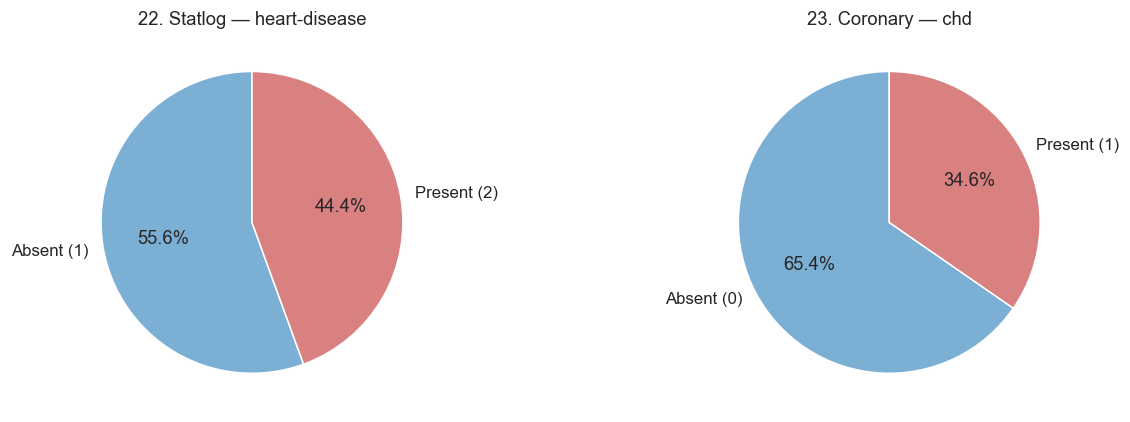

Statlog class counts:
 heart-disease
Absent     150
Present    120
Name: count, dtype: int64

Coronary class counts:
 chd
Absent     302
Present    160
Name: count, dtype: int64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Statlog: heart-disease  1=absent, 2=present
vc_s = df_statlog['heart-disease'].map({1: 'Absent (1)', 2: 'Present (2)'}).value_counts()
axes[0].pie(vc_s, labels=vc_s.index, autopct='%1.1f%%',
            colors=['#7bafd4', '#d98080'], startangle=90)
axes[0].set_title('22. Statlog — heart-disease')

# Coronary: chd  0=absent, 1=present
vc_c = df_coronary['chd'].map({0: 'Absent (0)', 1: 'Present (1)'}).value_counts()
axes[1].pie(vc_c, labels=vc_c.index, autopct='%1.1f%%',
            colors=['#7bafd4', '#d98080'], startangle=90)
axes[1].set_title('23. Coronary — chd')

plt.tight_layout()
plt.show()

print('Statlog class counts:\n', df_statlog['heart-disease'].value_counts().rename({1:'Absent',2:'Present'}))
print()
print('Coronary class counts:\n', df_coronary['chd'].value_counts().rename({0:'Absent',1:'Present'}))

## Feature Distributions — 22. Statlog

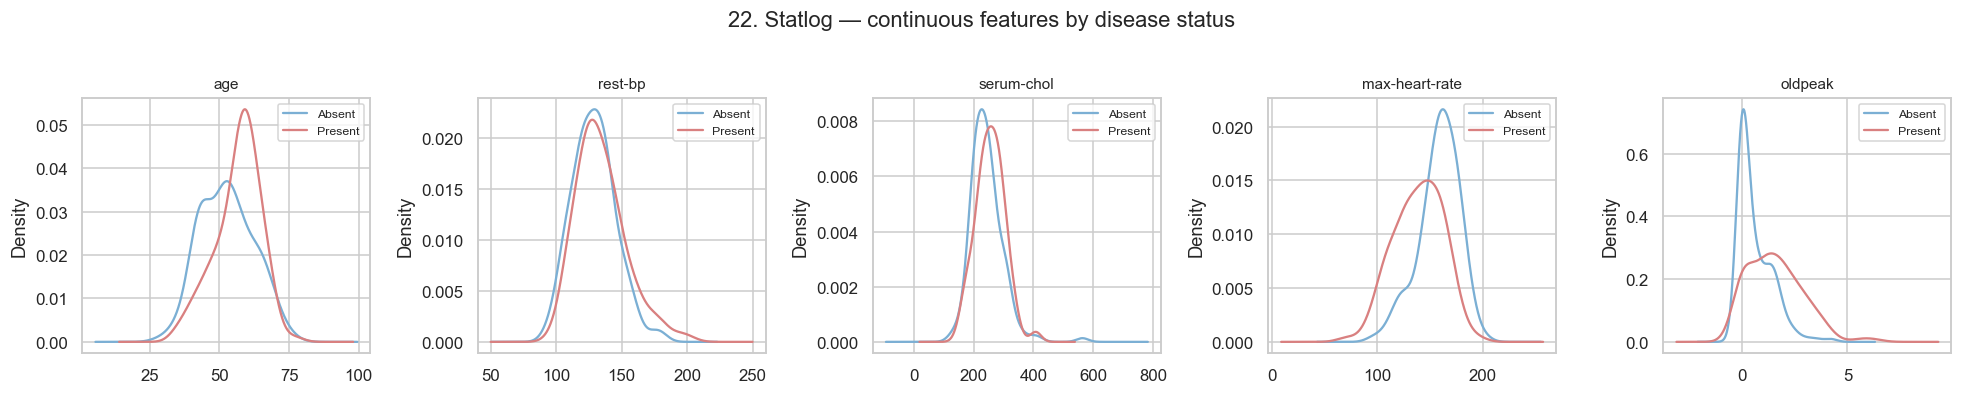

In [13]:
# Continuous features
cont_s = ['age', 'rest-bp', 'serum-chol', 'max-heart-rate', 'oldpeak']

fig, axes = plt.subplots(1, len(cont_s), figsize=(18, 3.5))
for ax, col in zip(axes, cont_s):
    for label, grp in df_statlog.groupby('heart-disease')[col]:
        grp.dropna().plot(kind='kde', ax=ax,
                          label=('Absent' if label == 1 else 'Present'),
                          color=('#7bafd4' if label == 1 else '#d98080'))
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

fig.suptitle('22. Statlog — continuous features by disease status', y=1.02)
plt.tight_layout()
plt.show()

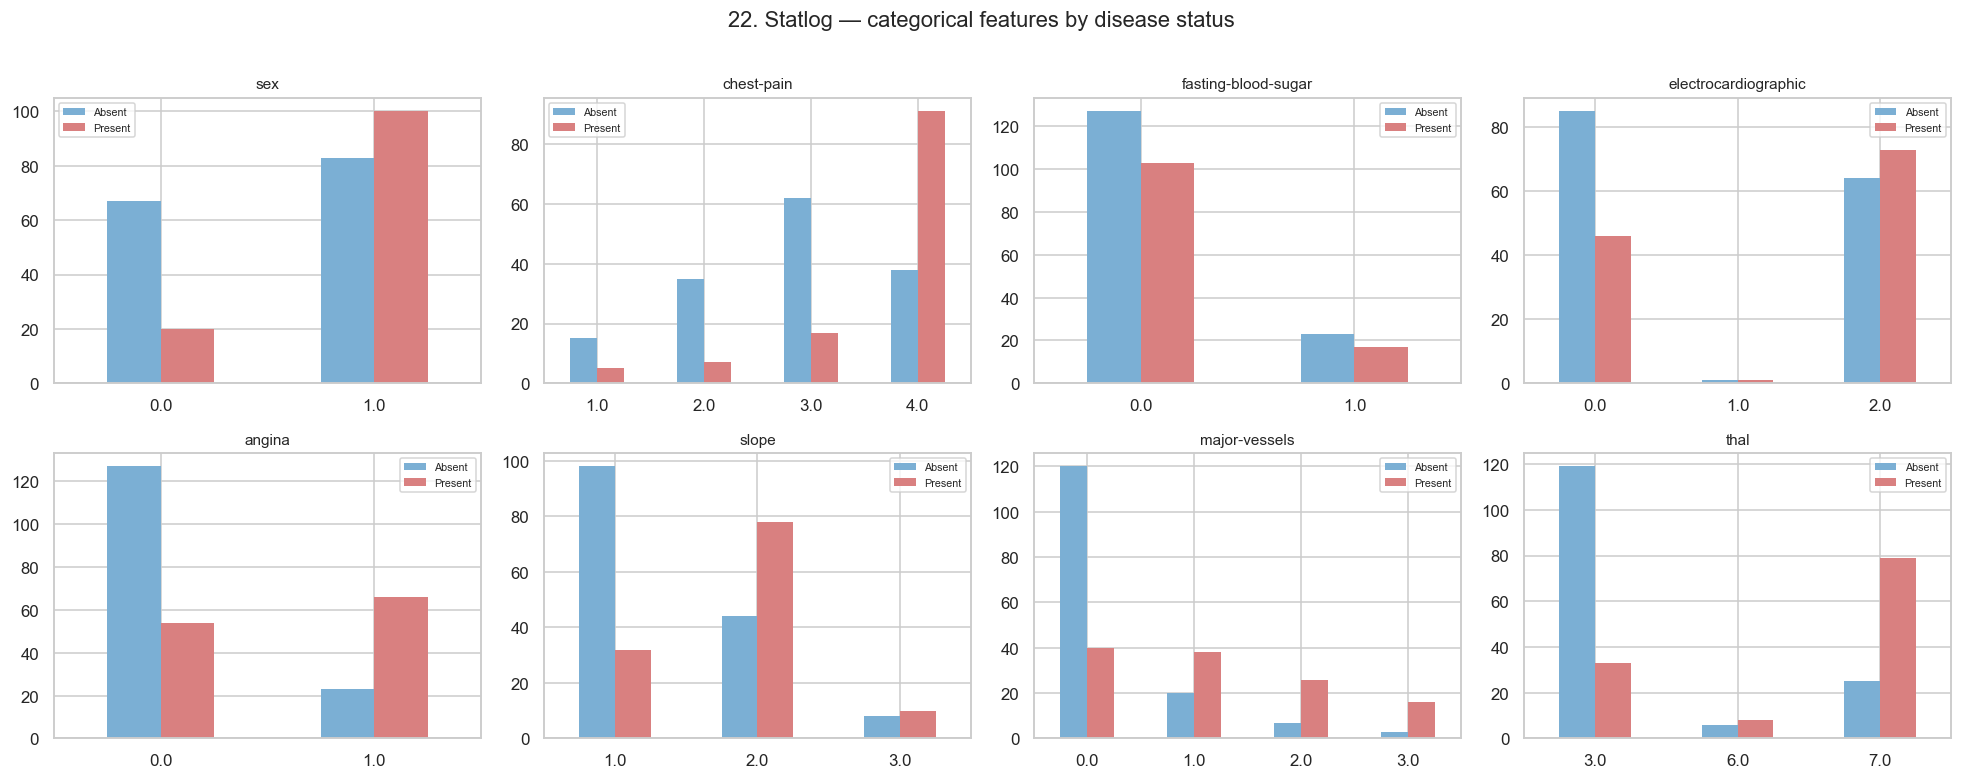

In [14]:
# Categorical / binary features
cat_s = ['sex', 'chest-pain', 'fasting-blood-sugar',
         'electrocardiographic', 'angina', 'slope', 'major-vessels', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for ax, col in zip(axes, cat_s):
    ct = pd.crosstab(
        df_statlog[col],
        df_statlog['heart-disease'].map({1: 'Absent', 2: 'Present'})
    )
    ct.plot(kind='bar', ax=ax, color=['#7bafd4', '#d98080'],
            edgecolor='none', legend=True, rot=0)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

fig.suptitle('22. Statlog — categorical features by disease status', y=1.01)
plt.tight_layout()
plt.show()

## Feature Distributions — 23. Coronary

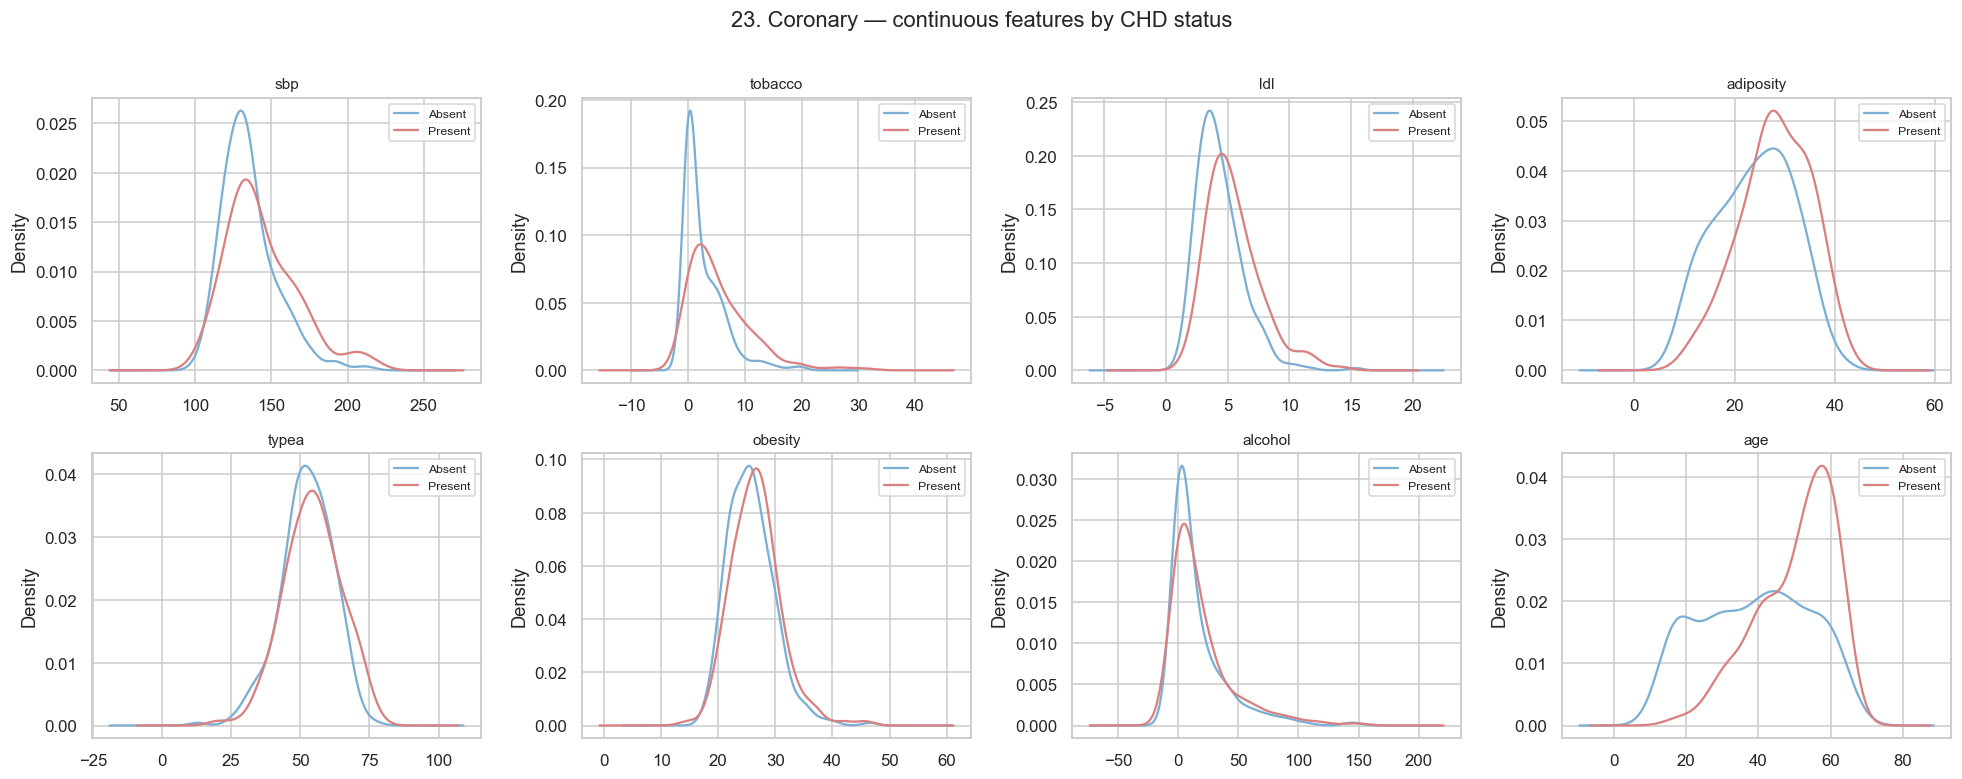

In [15]:
cont_c = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for ax, col in zip(axes, cont_c):
    for label, grp in df_coronary.groupby('chd')[col]:
        grp.plot(kind='kde', ax=ax,
                 label=('Absent' if label == 0 else 'Present'),
                 color=('#7bafd4' if label == 0 else '#d98080'))
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

fig.suptitle('23. Coronary — continuous features by CHD status', y=1.01)
plt.tight_layout()
plt.show()

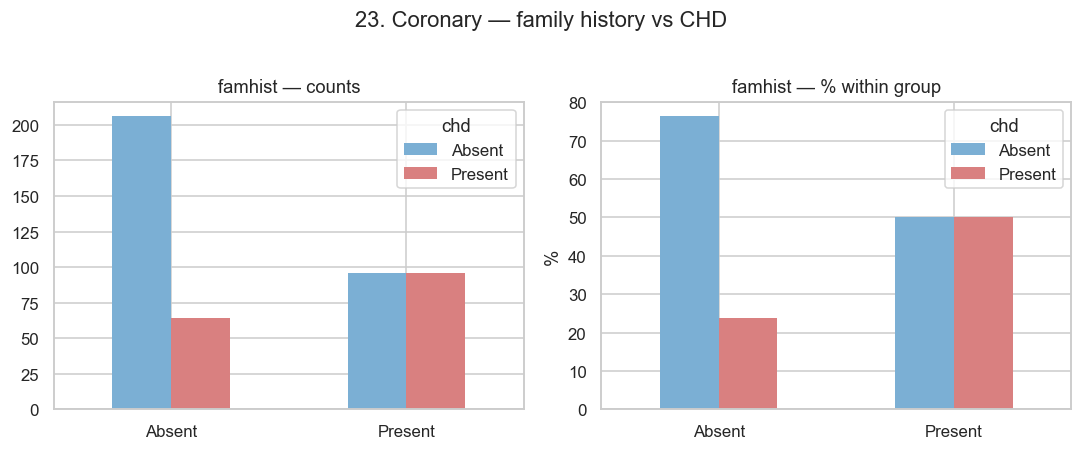

In [16]:
# famhist is the only categorical feature
ct = pd.crosstab(
    df_coronary['famhist'],
    df_coronary['chd'].map({0: 'Absent', 1: 'Present'})
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ct.plot(kind='bar', ax=axes[0], color=['#7bafd4', '#d98080'], rot=0, edgecolor='none')
axes[0].set_title('famhist — counts')
axes[0].set_xlabel('')

ct_pct.plot(kind='bar', ax=axes[1], color=['#7bafd4', '#d98080'], rot=0, edgecolor='none')
axes[1].set_title('famhist — % within group')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')

plt.suptitle('23. Coronary — family history vs CHD', y=1.02)
plt.tight_layout()
plt.show()

## Correlation Heatmap

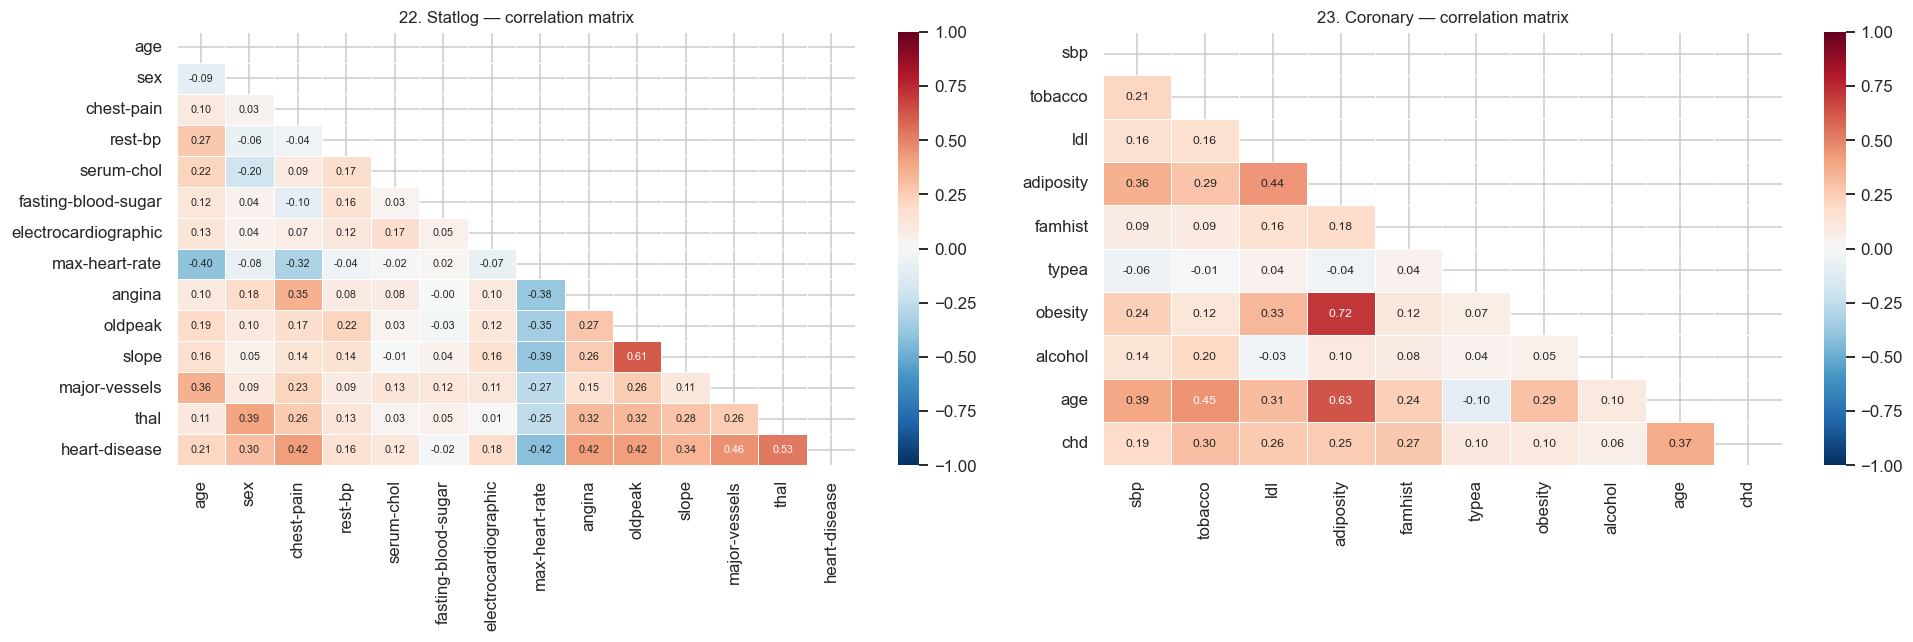

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Statlog — encode target temporarily for correlation
tmp_s = df_statlog.copy()
tmp_s['heart-disease'] = (tmp_s['heart-disease'] == 2).astype(int)
corr_s = tmp_s.corr()

mask_s = np.triu(np.ones_like(corr_s, dtype=bool))
sns.heatmap(corr_s, mask=mask_s, ax=axes[0],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4)
axes[0].set_title('22. Statlog — correlation matrix', fontsize=11)

# Coronary — encode famhist
tmp_c = df_coronary.copy()
tmp_c['famhist'] = (tmp_c['famhist'] == 'Present').astype(int)
corr_c = tmp_c.corr()

mask_c = np.triu(np.ones_like(corr_c, dtype=bool))
sns.heatmap(corr_c, mask=mask_c, ax=axes[1],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.4)
axes[1].set_title('23. Coronary — correlation matrix', fontsize=11)

plt.tight_layout()
plt.show()

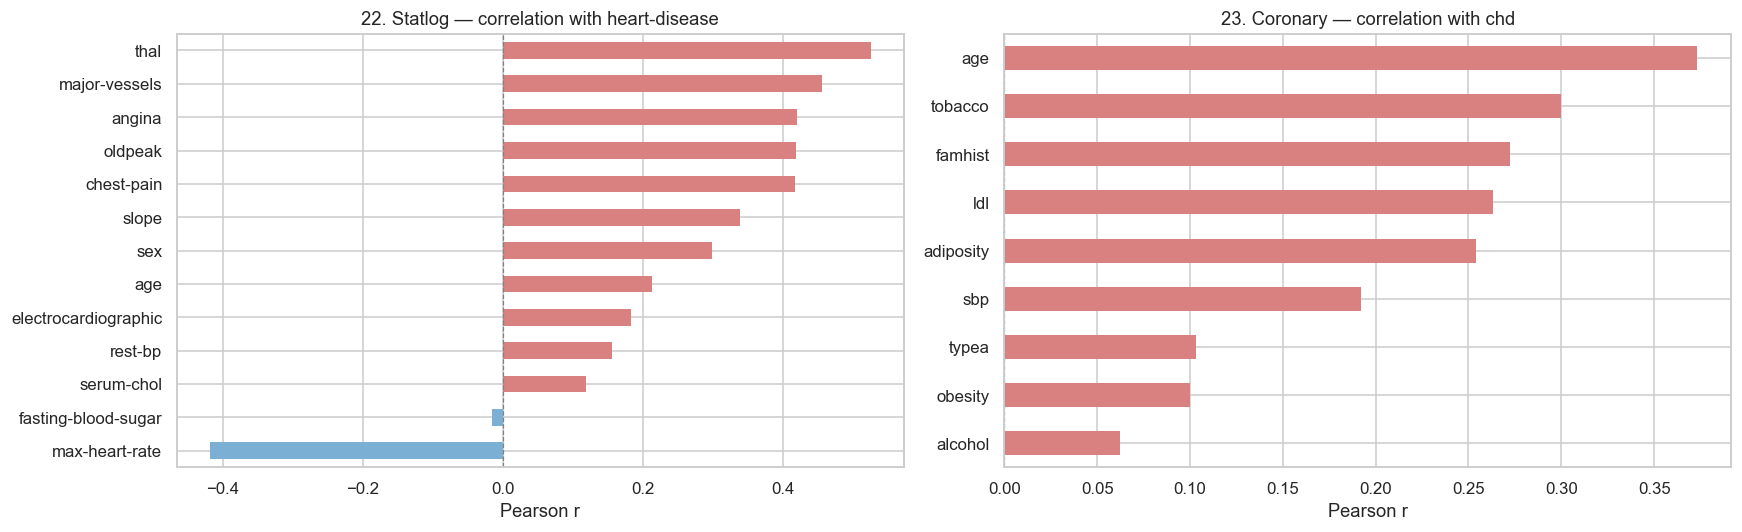

In [18]:
# Correlation with target — sorted bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

corr_target_s = corr_s['heart-disease'].drop('heart-disease').sort_values()
colors_s = ['#d98080' if v > 0 else '#7bafd4' for v in corr_target_s]
corr_target_s.plot(kind='barh', ax=axes[0], color=colors_s, edgecolor='none')
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('22. Statlog — correlation with heart-disease')
axes[0].set_xlabel('Pearson r')

corr_target_c = corr_c['chd'].drop('chd').sort_values()
colors_c = ['#d98080' if v > 0 else '#7bafd4' for v in corr_target_c]
corr_target_c.plot(kind='barh', ax=axes[1], color=colors_c, edgecolor='none')
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('23. Coronary — correlation with chd')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

---
# Data Processing

Steps applied to both datasets:
1. **Handle missing values** — median imputation for numerical columns
2. **Encode categorical features** — binary mapping
3. **Standardise the target** — both become `0 = no disease, 1 = disease`
4. **Normalise continuous features** — MinMax scaling to [0, 1]

## 22. Statlog — Processing

In [19]:
# ── Step 1: Check & impute missing values ─────────────────────────────
print('Missing values BEFORE imputation:')
print(df_statlog.isnull().sum()[df_statlog.isnull().sum() > 0])

df_s = df_statlog.copy()

# major-vessels and thal have rare NaN — fill with median
for col in ['major-vessels', 'thal']:
    median_val = df_s[col].median()
    df_s[col] = df_s[col].fillna(median_val)
    print(f'  Imputed "{col}" with median = {median_val}')

print('\nMissing values AFTER imputation:', df_s.isnull().sum().sum())

Missing values BEFORE imputation:
Series([], dtype: int64)
  Imputed "major-vessels" with median = 0.0
  Imputed "thal" with median = 3.0

Missing values AFTER imputation: 0


In [20]:
# ── Step 2: Encode target — 1=absent → 0, 2=present → 1 ──────────────
df_s['heart_disease'] = (df_s['heart-disease'] == 2).astype(int)
df_s = df_s.drop(columns=['heart-disease'])

print('Target distribution after encoding:')
print(df_s['heart_disease'].value_counts().rename({0:'No disease (0)', 1:'Disease (1)'}))

Target distribution after encoding:
heart_disease
No disease (0)    150
Disease (1)       120
Name: count, dtype: int64


In [21]:
# ── Step 3: Re-encode thal (3/6/7 are nominal codes, not ordinal) ─────
#   3 = normal       → 0
#   6 = fixed defect → 1
#   7 = reversible   → 2
df_s['thal'] = df_s['thal'].map({3.0: 0, 6.0: 1, 7.0: 2})

print('thal after mapping:')
print(df_s['thal'].value_counts().sort_index())

thal after mapping:
thal
0    152
1     14
2    104
Name: count, dtype: int64


In [22]:
# ── Step 4: Normalise continuous features ─────────────────────────────
cont_s = ['age', 'rest-bp', 'serum-chol', 'max-heart-rate', 'oldpeak']

scaler_s = MinMaxScaler()
df_s[cont_s] = scaler_s.fit_transform(df_s[cont_s])

print('Continuous columns after MinMax scaling (should be [0, 1]):')
df_s[cont_s].agg(['min', 'max']).round(4)

Continuous columns after MinMax scaling (should be [0, 1]):


,age,rest-bp,serum-chol,max-heart-rate,oldpeak
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


In [23]:
print('=== 22. Statlog — final processed shape:', df_s.shape, '===')
print('Columns:', df_s.columns.tolist())
df_s.head()

=== 22. Statlog — final processed shape: (270, 14) ===
Columns: ['age', 'sex', 'chest-pain', 'rest-bp', 'serum-chol', 'fasting-blood-sugar', 'electrocardiographic', 'max-heart-rate', 'angina', 'oldpeak', 'slope', 'major-vessels', 'thal', 'heart_disease']


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart_disease
0,0.854167,1.0,4.0,0.339623,0.447489,0.0,2.0,0.290076,0.0,0.387097,2.0,3.0,0,1
1,0.791667,0.0,3.0,0.198113,1.000000,0.0,2.0,0.679389,0.0,0.258065,2.0,0.0,2,0
2,0.583333,1.0,2.0,0.283019,0.308219,0.0,0.0,0.534351,0.0,0.048387,1.0,0.0,2,1
3,0.729167,1.0,4.0,0.320755,0.312785,0.0,0.0,0.259542,1.0,0.032258,2.0,1.0,2,0
4,0.937500,0.0,2.0,0.245283,0.326484,0.0,2.0,0.381679,1.0,0.032258,1.0,1.0,0,0


## 23. Coronary — Processing

In [24]:
# ── Step 1: Check missing values ──────────────────────────────────────
print('Missing values:')
null_counts = df_coronary.isnull().sum()
print(null_counts)

df_c = df_coronary.copy()
if null_counts.sum() == 0:
    print('\n→ No missing values — no imputation needed.')

Missing values:
sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

→ No missing values — no imputation needed.


In [25]:
# ── Step 2: Encode famhist (Present/Absent → 1/0) ─────────────────────
print('famhist BEFORE:', df_c['famhist'].unique())

df_c['famhist'] = (df_c['famhist'] == 'Present').astype(int)

print('famhist AFTER: ', df_c['famhist'].unique())
print('Distribution:', df_c['famhist'].value_counts().to_dict())

famhist BEFORE: <StringArray>
['Present', 'Absent']
Length: 2, dtype: str
famhist AFTER:  [1 0]
Distribution: {0: 270, 1: 192}


In [26]:
# ── Step 3: Verify target (chd is already 0/1) ────────────────────────
print('Target distribution (chd):')
print(df_c['chd'].value_counts().rename({0:'No CHD (0)', 1:'CHD (1)'}))

Target distribution (chd):
chd
No CHD (0)    302
CHD (1)       160
Name: count, dtype: int64


In [27]:
# ── Step 4: Normalise continuous features ─────────────────────────────
# tobacco and alcohol are right-skewed — log-transform before scaling
for col in ['tobacco', 'alcohol']:
    df_c[col] = np.log1p(df_c[col])  # log(1 + x) handles zeros
    print(f'  Applied log1p to "{col}" (was right-skewed)')

cont_c = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']
scaler_c = MinMaxScaler()
df_c[cont_c] = scaler_c.fit_transform(df_c[cont_c])

print('\nContinuous columns after scaling (should be [0, 1]):')
df_c[cont_c].agg(['min', 'max']).round(4)

  Applied log1p to "tobacco" (was right-skewed)
  Applied log1p to "alcohol" (was right-skewed)

Continuous columns after scaling (should be [0, 1]):


,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [28]:
print('=== 23. Coronary — final processed shape:', df_c.shape, '===')
print('Columns:', df_c.columns.tolist())
df_c.head()

=== 23. Coronary — final processed shape: (462, 10) ===
Columns: ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age', 'chd']


,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,0.504274,0.738760,0.331010,0.457902,1,0.553846,0.332497,0.917677,0.755102,1
1,0.367521,0.002866,0.239024,0.611748,0,0.646154,0.444479,0.223750,0.979592,1
2,0.145299,0.022166,0.174216,0.714406,1,0.600000,0.452949,0.314234,0.632653,0
3,0.589744,0.616384,0.378397,0.875245,1,0.584615,0.542346,0.646039,0.877551,1
4,0.282051,0.772191,0.175610,0.588531,1,0.723077,0.354141,0.813502,0.693878,1


## Before vs After — Distribution Check

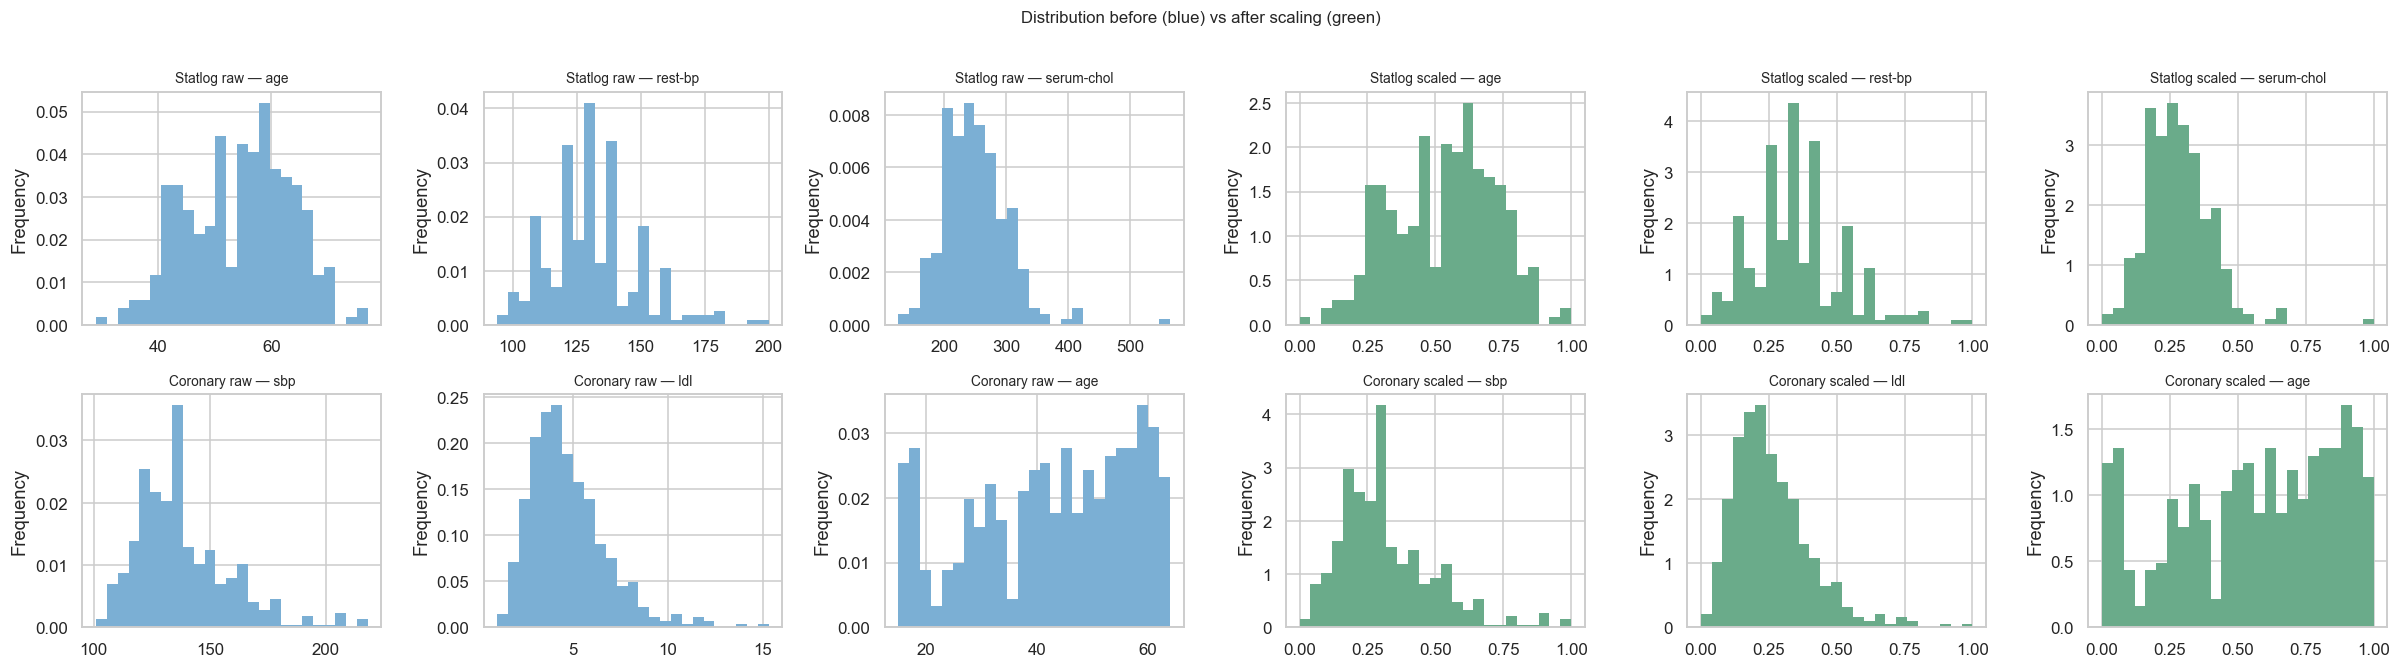

In [29]:
# Visual check: raw vs processed for key continuous cols
check_cols_s = ['age', 'rest-bp', 'serum-chol']
check_cols_c = ['sbp', 'ldl', 'age']

fig, axes = plt.subplots(2, 6, figsize=(22, 6))

for i, col in enumerate(check_cols_s):
    df_statlog[col].dropna().plot(kind='hist', bins=25, ax=axes[0, i],
                                  color='#7bafd4', edgecolor='none', density=True)
    axes[0, i].set_title(f'Statlog raw — {col}', fontsize=9)

    df_s[col].plot(kind='hist', bins=25, ax=axes[0, i+3],
                   color='#6aab8a', edgecolor='none', density=True)
    axes[0, i+3].set_title(f'Statlog scaled — {col}', fontsize=9)

for i, col in enumerate(check_cols_c):
    df_coronary[col].plot(kind='hist', bins=25, ax=axes[1, i],
                          color='#7bafd4', edgecolor='none', density=True)
    axes[1, i].set_title(f'Coronary raw — {col}', fontsize=9)

    df_c[col].plot(kind='hist', bins=25, ax=axes[1, i+3],
                   color='#6aab8a', edgecolor='none', density=True)
    axes[1, i+3].set_title(f'Coronary scaled — {col}', fontsize=9)

fig.suptitle('Distribution before (blue) vs after scaling (green)', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

## Save Processed Datasets

In [30]:
df_s.to_csv('data/22-statlog-processed.csv', index=False)
df_c.to_csv('data/23-coronary-processed.csv', index=False)

print('Saved:')
print('  data/22-statlog-processed.csv  →', df_s.shape)
print('  data/23-coronary-processed.csv →', df_c.shape)

Saved:
  data/22-statlog-processed.csv  → (270, 14)
  data/23-coronary-processed.csv → (462, 10)


---
# Join — Merge Both Datasets

Both datasets share  and  and a binary disease target.
All other columns are dataset-specific — they will be **kept as ** for the dataset that does not have them.

| Column | Statlog | Coronary |
|---|---|---|
|  | ✓ | ✓ |
|  |  |  |
|  |  |  |
| , , , , , , , , , ,  | ✓ | — |
| , , , , , ,  | — | ✓ |

## Align Statlog to Unified Schema

In [31]:
merged_statlog = pd.DataFrame()

# Set data columns first so the index is established from df_s
merged_statlog["age"]            = df_s["age"]
merged_statlog["systolic_bp"]    = df_s["rest-bp"]
merged_statlog["sex"]            = df_s["sex"]
merged_statlog["chest_pain"]     = df_s["chest-pain"]
merged_statlog["serum_chol"]     = df_s["serum-chol"]
merged_statlog["fbs"]            = df_s["fasting-blood-sugar"]
merged_statlog["ecg"]            = df_s["electrocardiographic"]
merged_statlog["max_heart_rate"] = df_s["max-heart-rate"]
merged_statlog["angina"]         = df_s["angina"]
merged_statlog["oldpeak"]        = df_s["oldpeak"]
merged_statlog["slope"]          = df_s["slope"]
merged_statlog["major_vessels"]  = df_s["major-vessels"]
merged_statlog["thal"]           = df_s["thal"]
for col in ["tobacco","ldl","adiposity","family_history","typea","obesity","alcohol"]:
    merged_statlog[col] = np.nan
merged_statlog["has_disease"]    = df_s["heart_disease"]
# source set last to broadcast over established index
merged_statlog["source"]         = "statlog"

print("Statlog aligned:", merged_statlog.shape)
merged_statlog.head(3)

Statlog aligned: (270, 22)


,age,systolic_bp,sex,chest_pain,serum_chol,fbs,ecg,max_heart_rate,angina,oldpeak,...,thal,tobacco,ldl,adiposity,family_history,typea,obesity,alcohol,has_disease,source
0,0.854167,0.339623,1.0,4.0,0.447489,0.0,2.0,0.290076,0.0,0.387097,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,statlog
1,0.791667,0.198113,0.0,3.0,1.000000,0.0,2.0,0.679389,0.0,0.258065,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,statlog
2,0.583333,0.283019,1.0,2.0,0.308219,0.0,0.0,0.534351,0.0,0.048387,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,statlog


## Align Coronary to Unified Schema

In [32]:
merged_coronary = pd.DataFrame()

merged_coronary["age"]            = df_c["age"]
merged_coronary["systolic_bp"]    = df_c["sbp"]
for col in ["sex","chest_pain","serum_chol","fbs","ecg","max_heart_rate",
             "angina","oldpeak","slope","major_vessels","thal"]:
    merged_coronary[col] = np.nan
merged_coronary["tobacco"]        = df_c["tobacco"]
merged_coronary["ldl"]            = df_c["ldl"]
merged_coronary["adiposity"]      = df_c["adiposity"]
merged_coronary["family_history"] = df_c["famhist"]
merged_coronary["typea"]          = df_c["typea"]
merged_coronary["obesity"]        = df_c["obesity"]
merged_coronary["alcohol"]        = df_c["alcohol"]
merged_coronary["has_disease"]    = df_c["chd"]
merged_coronary["source"]         = "coronary"

print("Coronary aligned:", merged_coronary.shape)
merged_coronary.head(3)

Coronary aligned: (462, 22)


,age,systolic_bp,sex,chest_pain,serum_chol,fbs,ecg,max_heart_rate,angina,oldpeak,...,thal,tobacco,ldl,adiposity,family_history,typea,obesity,alcohol,has_disease,source
0,0.755102,0.504274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.738760,0.331010,0.457902,1,0.553846,0.332497,0.917677,1,coronary
1,0.979592,0.367521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.002866,0.239024,0.611748,0,0.646154,0.444479,0.223750,1,coronary
2,0.632653,0.145299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.022166,0.174216,0.714406,1,0.600000,0.452949,0.314234,0,coronary


## Concatenate

In [33]:
df_merged = pd.concat([merged_statlog, merged_coronary], ignore_index=True)

n_s = (df_merged["source"]=="statlog").sum()
n_c = (df_merged["source"]=="coronary").sum()
print("Merged shape:", df_merged.shape)
print("  Statlog rows :", n_s)
print("  Coronary rows:", n_c)
print("Target balance:")
print(df_merged["has_disease"].value_counts().rename({0:"No disease",1:"Disease"}))
df_merged.head()

Merged shape: (732, 22)
  Statlog rows : 270
  Coronary rows: 462
Target balance:
has_disease
No disease    452
Disease       280
Name: count, dtype: int64


,age,systolic_bp,sex,chest_pain,serum_chol,fbs,ecg,max_heart_rate,angina,oldpeak,...,thal,tobacco,ldl,adiposity,family_history,typea,obesity,alcohol,has_disease,source
0,0.854167,0.339623,1.0,4.0,0.447489,0.0,2.0,0.290076,0.0,0.387097,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,statlog
1,0.791667,0.198113,0.0,3.0,1.000000,0.0,2.0,0.679389,0.0,0.258065,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,statlog
2,0.583333,0.283019,1.0,2.0,0.308219,0.0,0.0,0.534351,0.0,0.048387,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,statlog
3,0.729167,0.320755,1.0,4.0,0.312785,0.0,0.0,0.259542,1.0,0.032258,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,statlog
4,0.937500,0.245283,0.0,2.0,0.326484,0.0,2.0,0.381679,1.0,0.032258,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,statlog


## Null Coverage Map

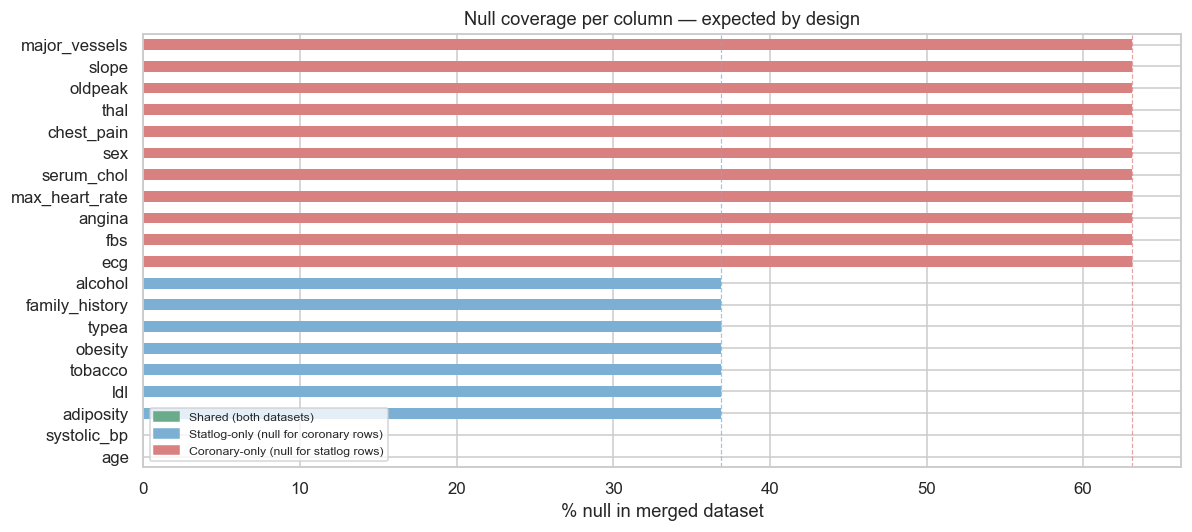

Null % per column:
age                0.0
systolic_bp        0.0
sex               63.1
chest_pain        63.1
serum_chol        63.1
fbs               63.1
ecg               63.1
max_heart_rate    63.1
angina            63.1
oldpeak           63.1
slope             63.1
major_vessels     63.1
thal              63.1
tobacco           36.9
ldl               36.9
adiposity         36.9
family_history    36.9
typea             36.9
obesity           36.9
alcohol           36.9


In [34]:
null_pct = df_merged.drop(columns=["source","has_disease"]).isnull().mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
sorted_vals = null_pct.sort_values(ascending=True)
bar_colors = ["#d98080" if v > 50 else "#7bafd4" if v > 0 else "#6aab8a" for v in sorted_vals]
sorted_vals.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="none")
ax.axvline(63.1, color="#d98080", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(36.9, color="#7bafd4", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xlabel("% null in merged dataset")
ax.set_title("Null coverage per column — expected by design")
import matplotlib.patches as mpatches
p1 = mpatches.Patch(color="#6aab8a", label="Shared (both datasets)")
p2 = mpatches.Patch(color="#7bafd4", label="Statlog-only (null for coronary rows)")
p3 = mpatches.Patch(color="#d98080", label="Coronary-only (null for statlog rows)")
ax.legend(handles=[p1,p2,p3], fontsize=8)
plt.tight_layout()
plt.show()

print("Null % per column:")
print(null_pct.round(1).to_string())

## Disease Balance by Source

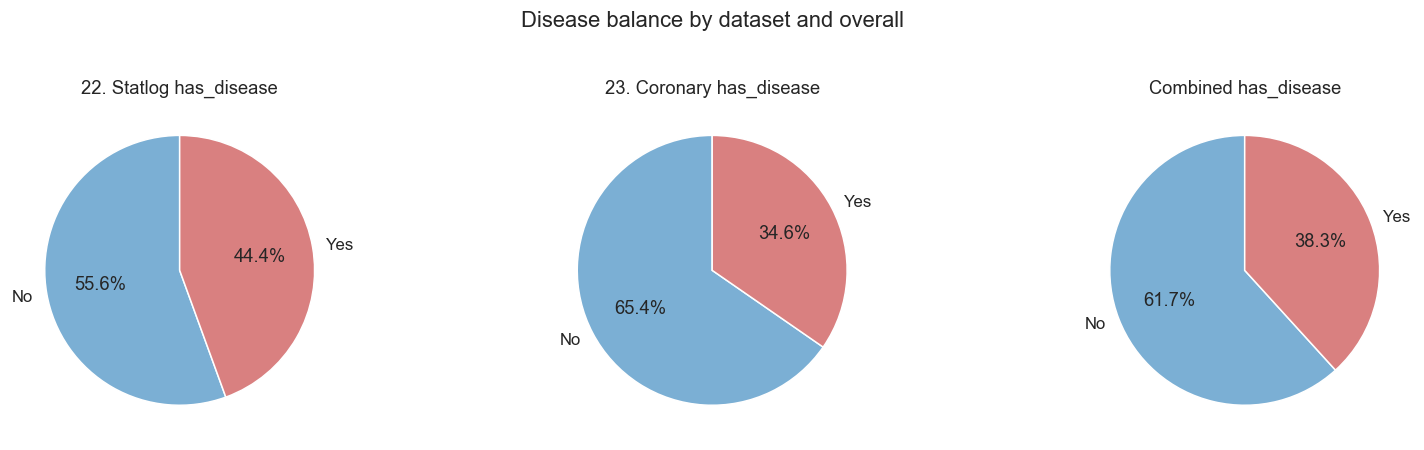

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, src, title in zip(
    axes[:2],
    ["statlog", "coronary"],
    ["22. Statlog", "23. Coronary"]
):
    vc = df_merged[df_merged["source"]==src]["has_disease"].value_counts().rename({0:"No",1:"Yes"})
    ax.pie(vc, labels=vc.index, autopct="%1.1f%%",
           colors=["#7bafd4","#d98080"], startangle=90)
    ax.set_title(title + " has_disease")

vc_all = df_merged["has_disease"].value_counts().rename({0:"No",1:"Yes"})
axes[2].pie(vc_all, labels=vc_all.index, autopct="%1.1f%%",
            colors=["#7bafd4","#d98080"], startangle=90)
axes[2].set_title("Combined has_disease")

plt.suptitle("Disease balance by dataset and overall", y=1.02)
plt.tight_layout()
plt.show()

## Shared Features — Cross-Dataset Distribution Check

 and  come from both datasets. Check they are on the same scale after normalization.

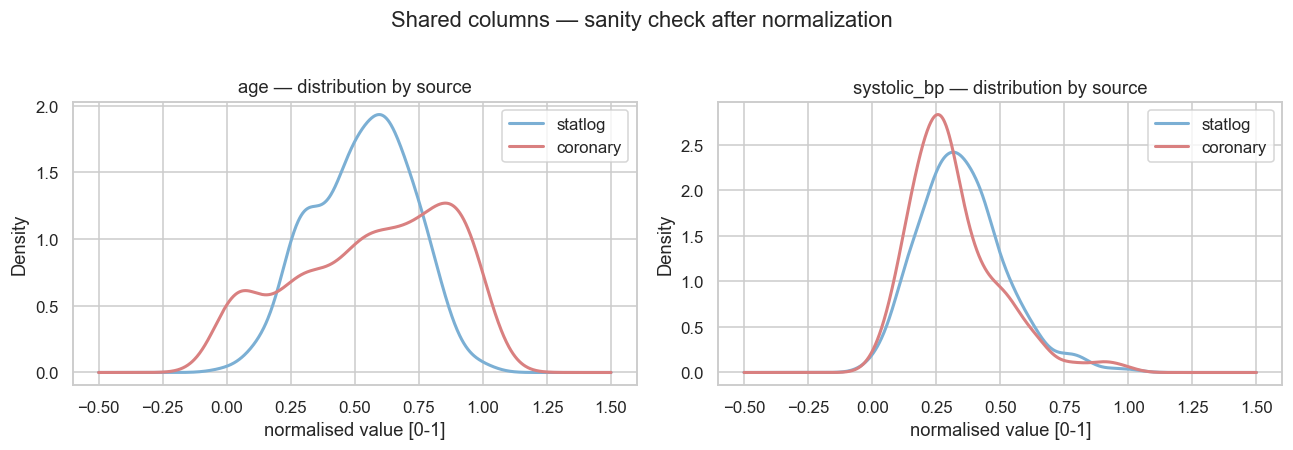

age stats by source:
          count   mean    std  min    25%    50%    75%  max
source                                                      
coronary  462.0  0.568  0.298  0.0  0.327  0.612  0.816  1.0
statlog   270.0  0.530  0.190  0.0  0.396  0.542  0.667  1.0
systolic_bp stats by source:
          count   mean    std  min    25%    50%    75%  max
source                                                      
coronary  462.0  0.319  0.175  0.0  0.197  0.282  0.402  1.0
statlog   270.0  0.352  0.169  0.0  0.245  0.340  0.434  1.0


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["age", "systolic_bp"]):
    for src, color in [("statlog","#7bafd4"),("coronary","#d98080")]:
        df_merged[df_merged["source"]==src][col].plot(
            kind="kde", ax=ax, label=src, color=color, linewidth=2)
    ax.set_title(col + " — distribution by source")
    ax.set_xlabel("normalised value [0-1]")
    ax.legend()

plt.suptitle("Shared columns — sanity check after normalization", y=1.02)
plt.tight_layout()
plt.show()

print("age stats by source:")
print(df_merged.groupby("source")["age"].describe().round(3))
print("systolic_bp stats by source:")
print(df_merged.groupby("source")["systolic_bp"].describe().round(3))

## Save Merged Dataset

In [37]:
df_merged.to_csv("data/merged.csv", index=False)

n_statlog = (df_merged["source"]=="statlog").sum()
n_coronary = (df_merged["source"]=="coronary").sum()
n_disease = df_merged["has_disease"].sum()
n_healthy = (df_merged["has_disease"]==0).sum()
pct_disease = df_merged["has_disease"].mean() * 100
pct_healthy = 100 - pct_disease

print("Saved: data/merged.csv")
print(f"  Shape     : {df_merged.shape}")
print(f"  Rows      : {len(df_merged)} ({n_statlog} statlog + {n_coronary} coronary)")
print(f"  Columns   : {df_merged.shape[1]}")
print(f"  Disease=1 : {n_disease} ({pct_disease:.1f}%)")
print(f"  Disease=0 : {n_healthy} ({pct_healthy:.1f}%)")
print()
print(df_merged.dtypes)


Saved: data/merged.csv
  Shape     : (732, 22)
  Rows      : 732 (270 statlog + 462 coronary)
  Columns   : 22
  Disease=1 : 280 (38.3%)
  Disease=0 : 452 (61.7%)

age               float64
systolic_bp       float64
sex               float64
chest_pain        float64
serum_chol        float64
fbs               float64
ecg               float64
max_heart_rate    float64
angina            float64
oldpeak           float64
slope             float64
major_vessels     float64
thal              float64
tobacco           float64
ldl               float64
adiposity         float64
family_history    float64
typea             float64
obesity           float64
alcohol           float64
has_disease         int64
source                str
dtype: object
